<a href="https://colab.research.google.com/github/aaditi72/NLP-Assignment/blob/main/NLP_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
SRM Institute of Science and Technology
21CSE356T - Natural Language Processing
Formative Test III - Text Classification (News Category)

Dataset: AG News Classification Dataset
Task: Classify news articles into 4 categories: World, Sports, Business, Sci/Tech
Models: Naive Bayes, Support Vector Machine (SVM), Logistic Regression
Evaluation: Accuracy, F1-score
"""

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import re
import warnings
warnings.filterwarnings("ignore")

# 1. LOAD DATA

print("=" * 60)
print("AG News Text Classification")
print("=" * 60)

# AG News label mapping (1-indexed in dataset)
LABEL_MAP = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

def load_ag_news(train_path="train.csv", test_path="test.csv"):
    """Load AG News CSV files (no header row)."""
    cols = ["label", "title", "description"]
    train_df = pd.read_csv(
        train_path, header=None, names=cols,
        quoting=0,           # QUOTE_MINIMAL — handles quoted fields with commas
        encoding="utf-8",
        on_bad_lines="skip", # skip any malformed rows silently
        engine="python",
    )
    test_df = pd.read_csv(
        test_path, header=None, names=cols,
        quoting=0,
        encoding="utf-8",
        on_bad_lines="skip",
        engine="python",
    )
    # Ensure label is integer (sometimes read as string)
    train_df["label"] = pd.to_numeric(train_df["label"], errors="coerce")
    test_df["label"]  = pd.to_numeric(test_df["label"],  errors="coerce")
    train_df.dropna(subset=["label"], inplace=True)
    test_df.dropna(subset=["label"],  inplace=True)
    train_df["label"] = train_df["label"].astype(int)
    test_df["label"]  = test_df["label"].astype(int)
    return train_df, test_df

train_df, test_df = load_ag_news()

print(f"\nTraining samples : {len(train_df):,}")
print(f"Test samples     : {len(test_df):,}")
print(f"\nClass distribution (train):")
for lbl, name in LABEL_MAP.items():
    count = (train_df["label"] == lbl).sum()
    print(f"  {lbl} - {name:<10}: {count:,}")

# 2. PREPROCESSING

def preprocess(text: str) -> str:
    """
    Basic NLP preprocessing:
    - Lowercase
    - Remove HTML tags
    - Remove special characters & digits
    - Collapse whitespace
    """
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def combine_and_clean(df: pd.DataFrame) -> pd.Series:
    """Combine title + description and clean."""
    combined = df["title"].fillna("") + " " + df["description"].fillna("")
    return combined.apply(preprocess)

print("\n[1/4] Preprocessing text...")
X_train = combine_and_clean(train_df)
X_test  = combine_and_clean(test_df)
y_train = train_df["label"].values
y_test  = test_df["label"].values

print(f"  Sample cleaned text:\n  '{X_train.iloc[0][:80]}...'")

# 3. MODELS (TF-IDF + Classifier Pipelines)

models = {
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=50_000,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("clf", MultinomialNB(alpha=0.1)),
    ]),

    "SVM (LinearSVC)": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=50_000,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("clf", LinearSVC(C=1.0, max_iter=2000)),
    ]),

    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=50_000,
            sublinear_tf=True,
            stop_words="english"
        )),
        ("clf", LogisticRegression(C=5.0, max_iter=1000, solver="lbfgs",
                                   multi_class="multinomial")),
    ]),
}

# 4. TRAIN & EVALUATE

print("\n[2/4] Training models...")
results = {}

for name, pipeline in models.items():
    print(f"\n  ▶ {name}")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")

    results[name] = {
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "y_pred": y_pred,
    }

    print(f"    Accuracy      : {acc:.4f} ({acc*100:.2f}%)")
    print(f"    F1 (weighted) : {f1_w:.4f}")
    print(f"    F1 (macro)    : {f1_m:.4f}")

# ─────────────────────────────────────────────
# 5. DETAILED REPORT
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("[3/4] Detailed Classification Reports")
print("=" * 60)

target_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

for name, res in results.items():
    print(f"\n{'─'*40}")
    print(f"Model: {name}")
    print("─" * 40)
    print(classification_report(
        y_test, res["y_pred"],
        target_names=target_names,
        digits=4
    ))

# 6. SUMMARY TABLE

print("\n" + "=" * 60)
print("[4/4] Summary Comparison Table")
print("=" * 60)
print(f"{'Model':<22} {'Accuracy':>10} {'F1-Weighted':>12} {'F1-Macro':>10}")
print("-" * 56)
for name, res in results.items():
    print(f"{name:<22} {res['accuracy']:>10.4f} {res['f1_weighted']:>12.4f} {res['f1_macro']:>10.4f}")

best_model = max(results, key=lambda k: results[k]["accuracy"])
print(f"\n✅ Best Model: {best_model} "
      f"(Accuracy: {results[best_model]['accuracy']*100:.2f}%)")

print("\nDone! ✓")

AG News Text Classification

Training samples : 120,000
Test samples     : 7,600

Class distribution (train):
  1 - World     : 30,000
  2 - Sports    : 30,000
  3 - Business  : 30,000
  4 - Sci/Tech  : 30,000

[1/4] Preprocessing text...
  Sample cleaned text:
  'wall st bears claw back into the black reuters reuters short sellers wall street...'

[2/4] Training models...

  ▶ Naive Bayes
    Accuracy      : 0.9070 (90.70%)
    F1 (weighted) : 0.9066
    F1 (macro)    : 0.9066

  ▶ SVM (LinearSVC)
    Accuracy      : 0.9221 (92.21%)
    F1 (weighted) : 0.9219
    F1 (macro)    : 0.9219

  ▶ Logistic Regression
    Accuracy      : 0.9213 (92.13%)
    F1 (weighted) : 0.9212
    F1 (macro)    : 0.9212

[3/4] Detailed Classification Reports

────────────────────────────────────────
Model: Naive Bayes
────────────────────────────────────────
              precision    recall  f1-score   support

       World     0.9195    0.8953    0.9072      1900
      Sports     0.9521    0.9837    0.96

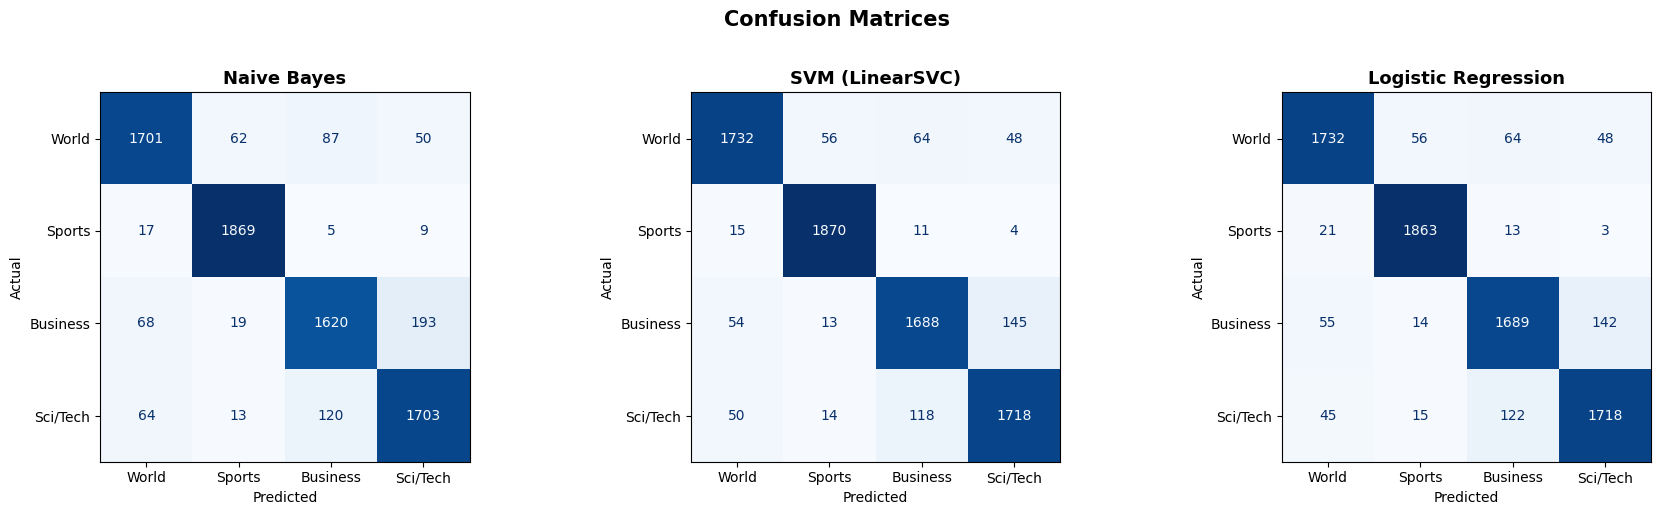

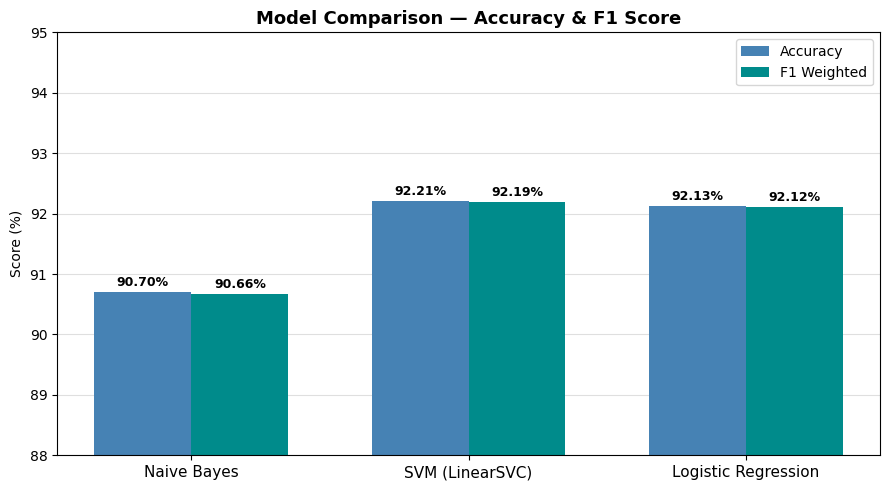

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes = ["World", "Sports", "Business", "Sci/Tech"]

# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pipeline) in zip(axes, models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Model Comparison Bar Chart ──
model_names = list(results.keys())
accuracies  = [results[m]["accuracy"] * 100 for m in model_names]
f1_scores   = [results[m]["f1_weighted"] * 100 for m in model_names]

x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, accuracies, w, label="Accuracy",    color="steelblue")
ax.bar(x + w/2, f1_scores,  w, label="F1 Weighted", color="darkcyan")

for i, (a, f) in enumerate(zip(accuracies, f1_scores)):
    ax.text(i - w/2, a + 0.1, f"{a:.2f}%", ha="center", fontsize=9, fontweight="bold")
    ax.text(i + w/2, f + 0.1, f"{f:.2f}%", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(88, 95)
ax.set_ylabel("Score (%)")
ax.set_title("Model Comparison — Accuracy & F1 Score", fontsize=13, fontweight="bold")
ax.legend()
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [ ]:
# DEMO

print("\n" + "=" * 60)
print("Demo: Predict on custom sentences")
print("=" * 60)

demo_texts = [
    "NASA launches new telescope to explore deep space galaxies",
    "Stock markets surge as inflation data comes in below expectations",
    "Champions League: Real Madrid beat Manchester City in stunning comeback",
    "UN Security Council holds emergency session on conflict in Middle East"
]

best_pipeline = models[best_model]
for text in demo_texts:
    cleaned  = preprocess(text)
    pred_lbl = best_pipeline.predict([cleaned])[0]
    print(f"  [{LABEL_MAP[pred_lbl]:<10}] {text}")


Demo: Predict on custom sentences
  [Sci/Tech  ] NASA launches new telescope to explore deep space galaxies
  [Business  ] Stock markets surge as inflation data comes in below expectations
  [Sports    ] Champions League: Real Madrid beat Manchester City in stunning comeback
  [World     ] UN Security Council holds emergency session on conflict in Middle East
